In [5]:
import pandas as pd
from pathlib import Path

required_files = ("users.csv", "posts.csv", "comments.csv")
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / "data-engineering" / "sample-data",
]

data_dir = next(
    (path for path in candidate_dirs if all((path / name).exists() for name in required_files)),
    None,
)

if data_dir is None:
    raise FileNotFoundError(
        "Could not find users.csv, posts.csv, and comments.csv from the current working directory."
    )

users_df = pd.read_csv(data_dir / "users.csv")
posts_df = pd.read_csv(data_dir / "posts.csv")
comments_df = pd.read_csv(data_dir / "comments.csv")

print(f"Data loaded from users.csv")
display(users_df)
print(f"Data loaded from posts.csv")
display(posts_df)
print(f"Data loaded from comments.csv")
display(comments_df)

Data loaded from users.csv


,id,name,email,role,created_at
0,1,Allison Hill,donaldgarcia@example.net,member,2026-02-22 22:47:46
1,2,Javier Johnson,jesseguzman@example.net,member,2026-01-20 07:19:31
2,3,Meredith Barnes,zlawrence@example.org,admin,2026-01-16 12:01:59
3,4,Gina Moore,curtis61@example.com,member,2026-02-03 09:28:29
4,5,Renee Blair,dudleynicholas@example.net,member,2026-01-29 11:09:17
5,6,Lisa Hensley,janetwilliams@example.org,member,2026-01-29 02:19:22
6,7,Dr. Sharon James,xreid@example.org,member,2026-02-05 22:35:03
7,8,Michael Miles,lynchgeorge@example.net,member,2026-01-24 18:27:02
8,9,James Mayo,gabriellecameron@example.org,admin,2026-01-23 05:43:14
9,10,Renee Morales,clarksherri@example.net,member,2026-01-31 13:15:09


Data loaded from posts.csv


,id,user_id,title,content,category,created_at
0,1,14,Human public health tonight later.,Ask again network open according. Arrive attac...,NEWS,2026-02-20 09:23:40
1,2,14,Economic type kitchen technology nearly anythi...,Unit support coach magazine.\nTotal clearly ab...,DISCUSSION,2026-02-21 17:27:48
2,3,1,Daughter respond draw how public.,First sell authority leader your you available...,ALERT,2026-02-06 16:59:48
3,4,11,Side PM energy scientist necessary into.,Away third tough nation.\nNeed involve among h...,NEWS,2026-02-17 16:01:11
4,5,3,Staff least figure somebody dinner.,Huge everything attorney significant go.\nQuic...,DISCUSSION,2026-02-15 17:22:32
5,6,1,Professor here security community notice image.,Expert involve oil pressure let.\nMemory soldi...,NEWS,2026-02-27 18:11:49
6,7,14,Compare when military anyone eat.,Card let most next fish sense kind. Interview ...,NEWS,2026-02-26 21:03:39
7,8,1,Section national owner determine detail job ah...,Right subject try wonder move trade. North agr...,ALERT,2026-02-17 12:48:46
8,9,14,Record short cold parent security boy standard.,Official up office traditional. However resour...,EVENT,2026-02-16 13:00:12
9,10,3,Something future they red everybody act.,Drop image new drive. Position make society be...,DISCUSSION,2026-02-12 19:20:44


Data loaded from comments.csv


,id,post_id,user_id,content,created_at
0,1,3,17,Develop development the inside.,2026-03-10 11:28:05
1,2,3,17,End family surface like term on.,2026-02-22 19:00:32
2,3,3,6,Line create build quite.,2026-03-08 20:06:42
3,4,3,2,Including that character yeah garden.,2026-03-04 10:18:11
4,5,3,17,Century television Congress ball forward would...,2026-03-06 08:23:59
...,...,...,...,...,...
215,216,27,20,Easy morning four.,2026-02-13 17:06:11
216,217,27,17,Adult range green few.,2026-03-03 18:24:40
217,218,27,14,Speech personal these three spring.,2026-03-09 00:04:03
218,219,28,15,We difficult game hotel case role minute.,2026-02-18 14:43:21


In [7]:
users_df.shape

(20, 5)

In [8]:
# Plot prep
import matplotlib.pyplot as plt

users = users_df.copy()
posts = posts_df.copy()
comments = comments_df.copy()

users["created_at"] = pd.to_datetime(users["created_at"])
posts["created_at"] = pd.to_datetime(posts["created_at"])
comments["created_at"] = pd.to_datetime(comments["created_at"])

author_lookup = users[["id", "name"]].rename(columns={"id": "user_id", "name": "author_name"})
posts = posts.merge(author_lookup, on="user_id", how="left")
comments = comments.merge(author_lookup, on="user_id", how="left")

plt.rcParams["figure.dpi"] = 120
posts[["author_name", "category", "created_at"]].head()


,author_name,category,created_at
0,Zachary Rice,NEWS,2026-02-20 09:23:40
1,Zachary Rice,DISCUSSION,2026-02-21 17:27:48
2,Allison Hill,ALERT,2026-02-06 16:59:48
3,Jonathan Wilkerson,NEWS,2026-02-17 16:01:11
4,Meredith Barnes,DISCUSSION,2026-02-15 17:22:32


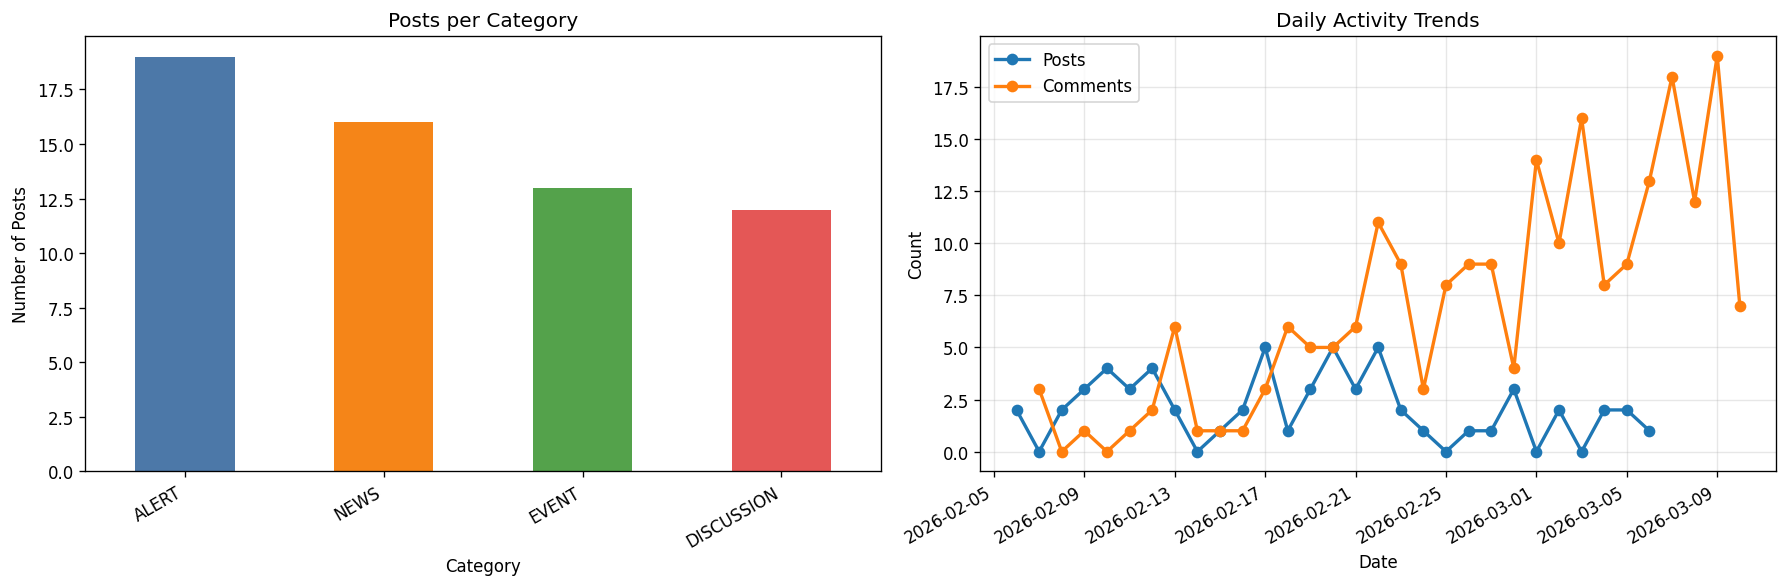

In [9]:
# Posts per category and activity trends
category_counts = posts["category"].value_counts().sort_values(ascending=False)
daily_posts = posts.set_index("created_at").resample("D").size()
daily_comments = comments.set_index("created_at").resample("D").size()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

category_counts.plot(
    kind="bar",
    ax=axes[0],
    color=["#4c78a8", "#f58518", "#54a24b", "#e45756"],
)
axes[0].set_title("Posts per Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Number of Posts")
axes[0].tick_params(axis="x", rotation=0)

axes[1].plot(daily_posts.index, daily_posts.values, marker="o", linewidth=2, label="Posts")
axes[1].plot(daily_comments.index, daily_comments.values, marker="o", linewidth=2, label="Comments")
axes[1].set_title("Daily Activity Trends")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()


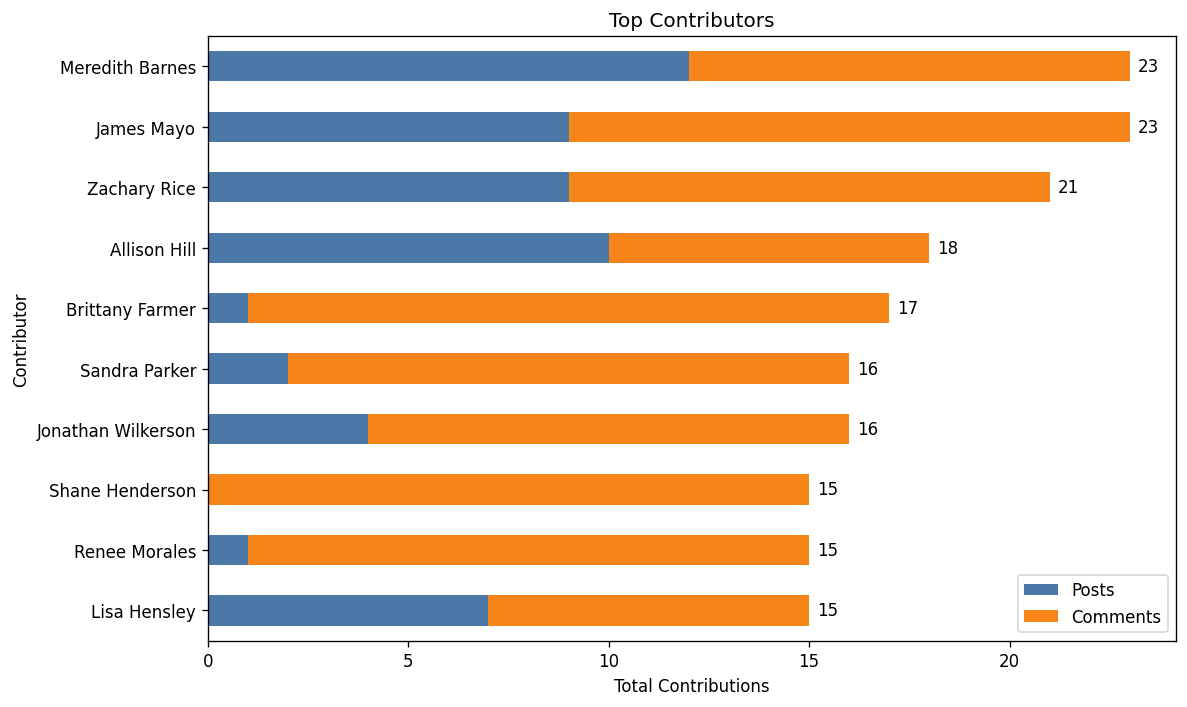

,Posts,Comments,Total
author_name,,,
Meredith Barnes,12,11,23
James Mayo,9,14,23
Zachary Rice,9,12,21
Allison Hill,10,8,18
Brittany Farmer,1,16,17
Jonathan Wilkerson,4,12,16
Sandra Parker,2,14,16
Lisa Hensley,7,8,15
Renee Morales,1,14,15


In [10]:
# Top contributors
post_counts = posts.groupby("author_name").size().rename("Posts")
comment_counts = comments.groupby("author_name").size().rename("Comments")

top_contributors = (
    pd.concat([post_counts, comment_counts], axis=1)
    .fillna(0)
    .astype(int)
    .assign(Total=lambda df: df["Posts"] + df["Comments"])
    .sort_values(["Total", "Posts"], ascending=False)
    .head(10)
    .sort_values("Total")
)

ax = top_contributors[["Posts", "Comments"]].plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6),
    color=["#4c78a8", "#f58518"],
)
ax.set_title("Top Contributors")
ax.set_xlabel("Total Contributions")
ax.set_ylabel("Contributor")
ax.legend(loc="lower right")

for index, total in enumerate(top_contributors["Total"]):
    ax.text(total + 0.2, index, str(total), va="center")

plt.tight_layout()
plt.show()

top_contributors.sort_values("Total", ascending=False)
